# Retail Return-Rate Modeling — Synthetic Portfolio Case Study

**Author:** Leonardo Flores · [LinkedIn](https://www.linkedin.com/in/leonardo-floresg/) · [GitHub](https://github.com/Luthiax)

> **Evidence boundary:** this notebook uses a synthetic Kaggle simulation. It demonstrates analytical process; it does not establish real retailer performance, causal effects, or realized savings.

## Questions

1. How accurately can a transparent Ridge model estimate the simulated `return_rate` on an untouched holdout?
2. Under explicit operating assumptions, what return reduction would make a three-year investment break even?

The predictive result and financial scenario are intentionally kept separate.

## 1. Setup and data quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.data_pipeline import RetailDataPipeline
from src.feature_engineering import RetailFeatureEngineer
from src.financial_sim import FinancialRiskSimulator

RANDOM_STATE = 42
TARGET = "return_rate"
EXCLUDED_FEATURES = ["customer_sentiment", "value_perception"]
sns.set_theme(style="whitegrid")

loader = RetailDataPipeline("RetailStoreProductSalesDataset.csv")
raw = loader.load_and_clean()
df = RetailFeatureEngineer().construct_features(raw)

quality = pd.Series({
    "rows": len(raw),
    "analytical_columns": raw.shape[1],
    "missing_cells": int(raw.isna().sum().sum()),
    "duplicate_rows": int(raw.duplicated().sum()),
    "mean_return_rate": raw[TARGET].mean(),
})
quality

2026-07-14 18:16:14,707 - INFO - Loading synthetic dataset from: RetailStoreProductSalesDataset.csv


2026-07-14 18:16:14,751 - INFO - Removed exported row-index column 'Unnamed: 0'.


2026-07-14 18:16:14,754 - INFO - Constructing derived retail features...


2026-07-14 18:16:14,759 - INFO - Feature engineering complete. Total features now: 14


rows                  15000.000000
analytical_columns       10.000000
missing_cells             0.000000
duplicate_rows            0.000000
mean_return_rate          0.063421
dtype: float64

### Feature-availability decision

The source describes `customer_sentiment` as estimated satisfaction. It does not verify that the field exists before purchase or before a return. The primary model therefore excludes it and the derived `value_perception` field. This is more conservative than assuming the variable is a pre-purchase rating.

## 2. Exploratory associations

Correlations below describe how simulated variables move together. They are not causal effects.

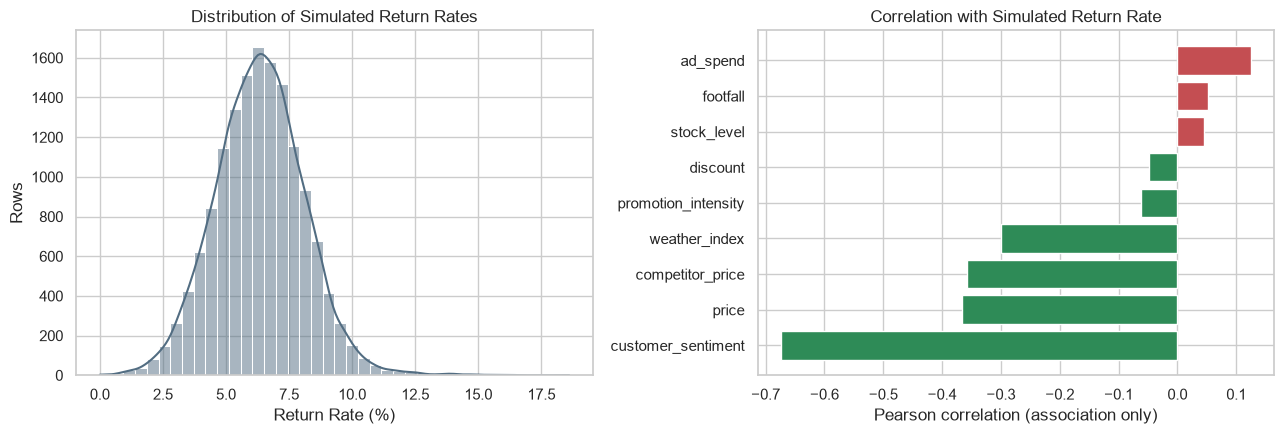

In [2]:
return_pct = raw[TARGET] * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(return_pct, bins=40, kde=True, color="#526D82", ax=axes[0])
axes[0].set(title="Distribution of Simulated Return Rates", xlabel="Return Rate (%)", ylabel="Rows")

corr = raw.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
colors = ["#2E8B57" if value < 0 else "#C44E52" for value in corr]
axes[1].barh(corr.index, corr.values, color=colors)
axes[1].set(title="Correlation with Simulated Return Rate", xlabel="Pearson correlation (association only)")
plt.tight_layout()
plt.show()

## 3. Leakage-aware model selection

The test partition is created before model selection and remains untouched. Standardization is inside the scikit-learn `Pipeline`, so the scaler is refit separately in every cross-validation fold. Ridge `alpha` is selected only on training data.

In [3]:
X = df.drop(columns=[TARGET, *EXCLUDED_FEATURES])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

estimator = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge()),
])

search = GridSearchCV(
    estimator=estimator,
    param_grid={"ridge__alpha": np.logspace(-3, 3, 25)},
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

model = search.best_estimator_
test_prediction = model.predict(X_test)
results = pd.Series({
    "selected_alpha": search.best_params_["ridge__alpha"],
    "training_cv_rmse": -search.best_score_,
    "holdout_rmse": mean_squared_error(y_test, test_prediction) ** 0.5,
    "holdout_r2": r2_score(y_test, test_prediction),
})
results

selected_alpha      10.000000
training_cv_rmse     0.015635
holdout_rmse         0.015817
holdout_r2           0.221281
dtype: float64

### Interpreting coefficients

The fitted coefficients are associations conditional on the other included fields. Several raw and ratio features are correlated, so individual magnitudes can be unstable. Do not translate a coefficient into a causal business lever.

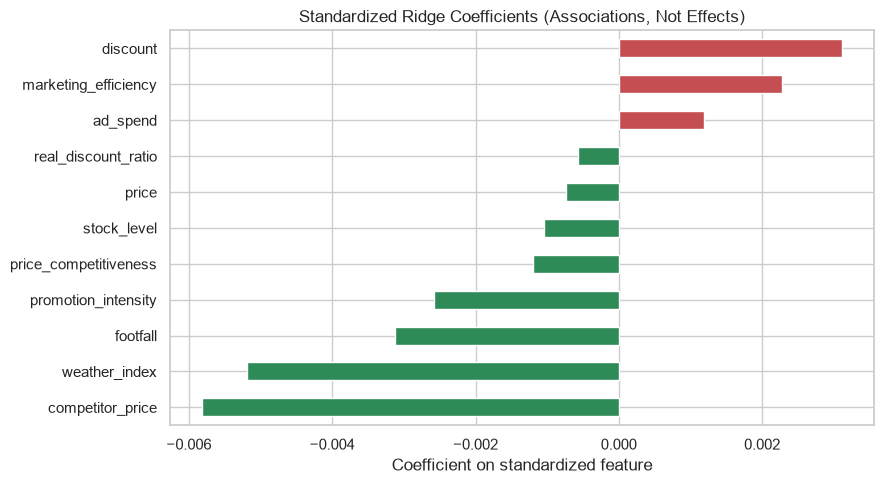

In [4]:
coef = pd.Series(model.named_steps["ridge"].coef_, index=X.columns).sort_values()
colors = ["#2E8B57" if value < 0 else "#C44E52" for value in coef]
ax = coef.plot.barh(figsize=(9, 5), color=colors)
ax.set_title("Standardized Ridge Coefficients (Associations, Not Effects)")
ax.set_xlabel("Coefficient on standardized feature")
plt.tight_layout()
plt.show()

## 4. Financial sensitivity scenario

This section does not use model predictions. It asks what the economics would be **if** an initiative achieved a specified reduction. The base assumptions—30,000 annual returns, USD 20 cost per return, 10% reduction, USD 50,000 capex, USD 15,000 annual opex, and a 10% discount rate—produce an illustrative three-year NPV of about USD 61,908.

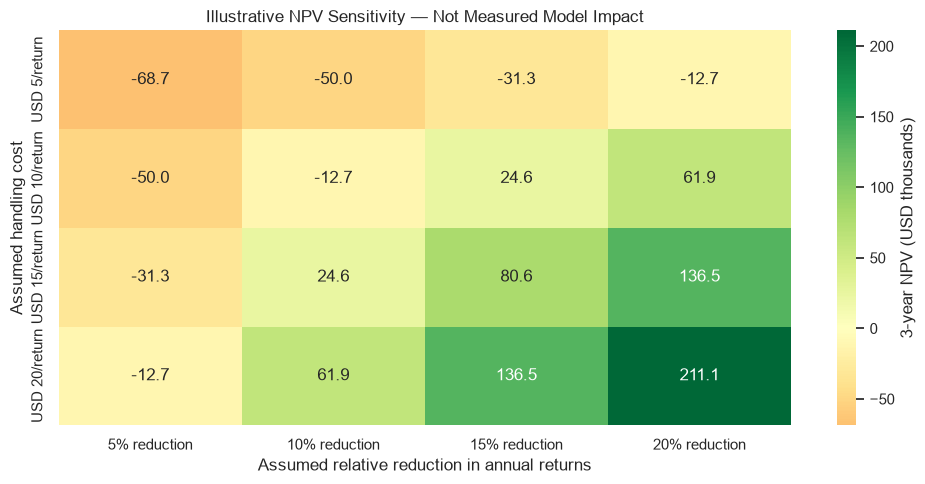

base_case_npv_usd      61908.339594
breakeven_reduction        0.058510
dtype: float64

In [5]:
simulator = FinancialRiskSimulator(capex=50_000, opex_annual=15_000, discount_rate=0.10)
cost_levels = [5, 10, 15, 20]
reduction_levels = [0.05, 0.10, 0.15, 0.20]

npv_grid = pd.DataFrame(
    [
        [simulator.simulate_3year_npv(cost, reduction, 30_000) / 1_000 for reduction in reduction_levels]
        for cost in cost_levels
    ],
    index=[f"USD {cost}/return" for cost in cost_levels],
    columns=[f"{reduction:.0%} reduction" for reduction in reduction_levels],
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(npv_grid, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "3-year NPV (USD thousands)"})
ax.set_title("Illustrative NPV Sensitivity — Not Measured Model Impact")
ax.set_xlabel("Assumed relative reduction in annual returns")
ax.set_ylabel("Assumed handling cost")
plt.tight_layout()
plt.show()

pd.Series({
    "base_case_npv_usd": simulator.simulate_3year_npv(20, 0.10, 30_000),
    "breakeven_reduction": simulator.breakeven_reduction(20, 30_000),
})

## 5. Conclusions and next validation step

This case study can support a claim about process: a conservative feature-availability decision, train-only model selection, one holdout evaluation, transparent assumptions, and explicit limits.

It cannot support claims about real SKUs, future weeks, causal return reduction, production deployment, or validated ROI. With real retailer data, the next steps would be: define the decision unit and intervention; use lagged, pre-decision features; validate across future time and unseen stores/products; and run a controlled pilot to measure incremental reduction and operational cost.